
# 🧬 Carpeta 3 — Optimización con Algoritmo Genético (AG)

**Proyecto:** Optimización Ambiental de la Semaforización Urbana mediante un Sistema de
Inferencia Difusa Multivariable (MIMO), Algoritmos Genéticos y Extracción de Reglas con PRISM.

**Universidad Técnica de Ambato — Carrera de Software — Inteligencia Artificial**

---

## Objetivo de esta libreta

Calibrar, mediante un **Algoritmo Genético (AG)** implementado con la librería **DEAP**, la
**posición de las funciones de pertenencia** de las 4 variables de entrada del sistema difuso
MIMO construido en la Carpeta 2, de modo que se **minimice el impacto ambiental**:

$$\text{Minimizar } f(x) = \texttt{emission\_estimate} + \texttt{air\_quality\_index}$$

tal como se planteó en la Sección II.3 (Ecuación 1) del documento del proyecto.

## Marco teórico (según la unidad "Optimización — Algoritmos Genéticos")

Un problema de optimización consiste en **hallar la mejor solución** $\theta = [\theta_1\;
\theta_2\;\dots\;\theta_N]$ (los **parámetros**) que **minimiza [o maximiza] una función de
costo** $\varphi(\theta)$. En un sistema difuso, los hiperparámetros optimizables son
precisamente **los parámetros de las funciones de pertenencia de los antecedentes** — que es
justo lo que este AG calibra (ver Paso 5).

Los **Algoritmos Genéticos** (Holland, 1975; Goldberg, 1989) son una técnica de **búsqueda
estocástica** inspirada en la selección natural de Darwin, que sigue el ciclo:

```
Población inicial (N individuos)
        ↓
Selección de padres  ←──────────────┐
        ↓                            │
Crossover (cruce)                    │
        ↓                            │
Mutación                             │
        ↓                            │
Selección de N individuos            │
        ↓                            │
   ¿Detención?  ── NO ───────────────┘
        │
       SÍ
        ↓
  Solución: el mejor individuo
```

La **función de aptitud** (*fitness function*) es la pieza clave: debe identificar las malas
soluciones y premiar a las buenas para que se propaguen (Paso 4/5 de esta libreta). Los
**hiperparámetros** del AG que hay que decidir son: tamaño de población, método de selección de
padres, método y probabilidad de mutación, método de creación de hijos (crossover), y
criterio de detención — decisiones que se documentan explícitamente en el Paso 6 de esta
libreta.

**Codificación del cromosoma — binaria vs. real.** El ejemplo introductorio clásico de un AG
codifica cada parámetro como una cadena de **bits concatenados** (p. ej. tres parámetros
enteros `X=155, Y=124, Z=228` se codifican como un único cromosoma binario de 24 bits). Sin
embargo, cuando los parámetros son **continuos** — como la posición de las funciones de
pertenencia de un sistema difuso — la propia unidad del curso (ver aplicación *"Optimización de
Funciones de Pertenencia"*, comparando Takagi-Sugeno vs. AG) usa una **codificación real**
(de punto flotante) directamente sobre los parámetros, evitando el costo de codificar/decodificar
binario y aprovechando que "los parámetros no necesitan ser escalados". Esta libreta sigue
exactamente ese mismo enfoque: **cada gen del cromosoma es directamente un umbral real** de una
función de pertenencia (ver Paso 5).

## Idea general del pipeline

1. El sistema difuso de la Carpeta 2 (`skfuzzy.control`) es preciso, pero **evaluarlo miles de
   veces** (como exige un AG con muchas generaciones) es computacionalmente costoso.
2. Por ello, aquí se reimplementa el **mismo** motor de inferencia difusa (mismas reglas PRISM,
   mismas funciones triangulares, mismo operador Y=mínimo) en una versión **vectorizada con
   NumPy** — matemáticamente equivalente salvo por el método de defuzzificación (promedio
   ponderado en vez de centroide completo, una simplificación estándar para acelerar cómputo).
   Esta versión se **valida contra `skfuzzy`** antes de usarla (Paso 3).
3. Como no se dispone de un simulador real de tráfico, se entrena un **modelo sustituto
   (surrogate)** sobre el propio dataset histórico, que aproxima
   `emission_estimate + air_quality_index` a partir de las condiciones de tráfico y de la
   decisión semafórica.
4. El AG evoluciona los **umbrales de las funciones de pertenencia** (cromosoma) para minimizar
   el costo ambiental estimado por el modelo sustituto sobre un lote de escenarios reales.


In [1]:

import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from deap import base, creator, tools

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('Librerías cargadas correctamente (incluye DEAP para el Algoritmo Genético).')


Librerías cargadas correctamente (incluye DEAP para el Algoritmo Genético).


## Paso 1 — Carga de datos, reglas PRISM y configuración del sistema difuso base

In [2]:

DATA_PATH = Path('../data/smart_city_traffic_mobility.csv')
RUTA_PRISM = Path('../01_Reglas_PRISM')
RUTA_DIFUSO = Path('../02_Sistema_Difuso_MIMO')

df = pd.read_csv(DATA_PATH, sep=';')
df['costo_ambiental'] = df['emission_estimate'] + df['air_quality_index']

with open(RUTA_PRISM / 'umbrales_discretizacion.json', encoding='utf-8') as f:
    umbrales = json.load(f)
with open(RUTA_PRISM / 'reglas_prism_green_light_duration.json', encoding='utf-8') as f:
    reglas_gld = json.load(f)
with open(RUTA_PRISM / 'reglas_prism_signal_cycle_adjustment.json', encoding='utf-8') as f:
    reglas_sca = json.load(f)
with open(RUTA_DIFUSO / 'config_sistema_difuso.json', encoding='utf-8') as f:
    config_difuso = json.load(f)

UMBRAL_CONFIANZA = config_difuso['umbral_confianza_regla']
reglas_gld_f = [r for r in reglas_gld if r['confianza'] >= UMBRAL_CONFIANZA]
reglas_sca_f = [r for r in reglas_sca if r['confianza'] >= UMBRAL_CONFIANZA]

VARIABLES = ['traffic_density', 'queue_length', 'vehicle_count', 'average_speed']
ETIQUETAS = config_difuso['etiquetas']
RANGOS = {v: tuple(config_difuso['rangos_entrada'][v]) for v in VARIABLES}
UMBRALES_BASE = {v: tuple(umbrales['entradas'][v]) for v in VARIABLES}
GLD_INFO = config_difuso['green_light_duration']
SCA_INFO = config_difuso['signal_cycle_adjustment']

print(f"Registros: {len(df):,}  |  Reglas GLD: {len(reglas_gld_f)}  |  Reglas SCA: {len(reglas_sca_f)}")
print('Umbrales base (heredados de PRISM):', UMBRALES_BASE)


Registros: 204,000  |  Reglas GLD: 28  |  Reglas SCA: 39
Umbrales base (heredados de PRISM): {'traffic_density': (23.8, 122.23333333333139), 'queue_length': (9.9, 44.4), 'vehicle_count': (204.0, 983.0), 'average_speed': (34.2, 53.6)}



## Paso 2 — Motor de inferencia difusa vectorizado (NumPy)

Se implementa `trimf_vectorizado` (equivalente a `skfuzzy.trimf` pero aplicado a arreglos
completos) y una función `inferir_lote` que evalúa la base de reglas PRISM sobre **todo un lote
de escenarios a la vez**, usando:

* **Conjunción (Y)** → mínimo de las pertenencias (idéntico a Mamdani/skfuzzy)
* **Agregación + defuzzificación** → **promedio ponderado** por el grado de disparo de cada
  regla (aproximación rápida y estándar del centroide, ampliamente usada en sistemas difusos
  optimizados por metaheurísticas por su bajo costo computacional)


In [3]:

def trimf_vectorizado(x, a, b, c):
    '''Función de pertenencia triangular vectorizada. a <= b <= c.'''
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    if b > a:
        izquierda = (x > a) & (x <= b)
        y[izquierda] = (x[izquierda] - a) / (b - a)
    if c > b:
        derecha = (x > b) & (x < c)
        y[derecha] = (c - x[derecha]) / (c - b)
    y[np.isclose(x, b)] = 1.0
    return np.clip(y, 0.0, 1.0)


def calcular_membresias(datos: dict, umbrales_var: dict) -> dict:
    '''Calcula, para cada variable y cada una de sus 3 etiquetas, el vector de membresía.'''
    memb = {}
    for var in VARIABLES:
        mn, mx = RANGOS[var]
        th1, th2 = umbrales_var[var]
        punto_medio = (th1 + th2) / 2
        etq = ETIQUETAS[var]
        memb[(var, etq[0])] = trimf_vectorizado(datos[var], mn, mn, th1)
        memb[(var, etq[1])] = trimf_vectorizado(datos[var], th1, punto_medio, th2)
        memb[(var, etq[2])] = trimf_vectorizado(datos[var], th2, mx, mx)
    return memb


# Valores representativos (centro de cada conjunto de salida) usados en el promedio ponderado
REP_GLD = {
    'Corta': (GLD_INFO['rango_min'] + GLD_INFO['corte_1']) / 2,
    'Media': (GLD_INFO['corte_1'] + GLD_INFO['corte_2']) / 2,
    'Larga': (GLD_INFO['corte_2'] + GLD_INFO['rango_max']) / 2,
}
REP_SCA = {
    'Reducir':  (SCA_INFO['rango_delta_min'] - SCA_INFO['umbral_delta']) / 2,
    'Mantener': 0.0,
    'Extender': (SCA_INFO['umbral_delta'] + SCA_INFO['rango_delta_max']) / 2,
}


def inferir_lote(datos: dict, umbrales_var: dict, reglas: list, representativos: dict) -> np.ndarray:
    '''Evalúa un lote completo de escenarios (arreglos NumPy) contra la base de reglas PRISM.'''
    memb = calcular_membresias(datos, umbrales_var)
    n = len(next(iter(datos.values())))
    numerador = np.zeros(n)
    denominador = np.zeros(n)
    for r in reglas:
        disparo = None
        for attr, valor in r['antecedente']:
            var = attr.replace('_lbl', '')
            m = memb[(var, valor)]
            disparo = m if disparo is None else np.minimum(disparo, m)
        clase = r['clase_objetivo']
        numerador += disparo * representativos[clase]
        denominador += disparo
    valor_respaldo = float(np.mean(list(representativos.values())))
    salida = np.where(denominador > 1e-9, numerador / np.where(denominador > 1e-9, denominador, 1), valor_respaldo)
    return salida


print('Motor de inferencia difusa vectorizado definido.')


Motor de inferencia difusa vectorizado definido.



## Paso 3 — Validación del motor vectorizado contra `skfuzzy.control`

Antes de usar el motor rápido para el AG, se comprueba que sus salidas son **consistentes** con
las del sistema difuso "oficial" de la Carpeta 2 (que usa centroide completo). Se comparan sobre
30 escenarios aleatorios.


In [4]:

import skfuzzy as fuzz
from skfuzzy import control as ctrl


def puntos_triangulares(min_v, th1, th2, max_v):
    punto_medio = (th1 + th2) / 2
    return {'bajo': [min_v, min_v, th1], 'medio': [th1, punto_medio, th2], 'alto': [th2, max_v, max_v]}


def construir_sistema_skfuzzy(umbrales_var):
    antecedentes = {}
    for var in VARIABLES:
        mn, mx = RANGOS[var]
        th1, th2 = umbrales_var[var]
        universo = np.linspace(mn, mx, 200)
        a = ctrl.Antecedent(universo, var)
        pts = puntos_triangulares(mn, th1, th2, mx)
        etq = ETIQUETAS[var]
        a[etq[0]] = fuzz.trimf(universo, pts['bajo'])
        a[etq[1]] = fuzz.trimf(universo, pts['medio'])
        a[etq[2]] = fuzz.trimf(universo, pts['alto'])
        antecedentes[var] = a

    uni_gld = np.linspace(GLD_INFO['rango_min'], GLD_INFO['rango_max'], 200)
    gld_cons = ctrl.Consequent(uni_gld, 'green_light_duration')
    pts = puntos_triangulares(GLD_INFO['rango_min'], GLD_INFO['corte_1'], GLD_INFO['corte_2'], GLD_INFO['rango_max'])
    gld_cons['Corta'] = fuzz.trimf(uni_gld, pts['bajo'])
    gld_cons['Media'] = fuzz.trimf(uni_gld, pts['medio'])
    gld_cons['Larga'] = fuzz.trimf(uni_gld, pts['alto'])

    def regla(r, cons):
        term = None
        for attr, val in r['antecedente']:
            var = attr.replace('_lbl', '')
            t = antecedentes[var][val]
            term = t if term is None else (term & t)
        return ctrl.Rule(term, cons[r['clase_objetivo']])

    reglas_ctrl = [regla(r, gld_cons) for r in reglas_gld_f]
    return ctrl.ControlSystem(reglas_ctrl), antecedentes, gld_cons


sistema_val, _, _ = construir_sistema_skfuzzy(UMBRALES_BASE)

muestra_val = df.sample(30, random_state=1)
salidas_skfuzzy, salidas_vectorial = [], []
datos_val = {v: muestra_val[v].clip(upper=RANGOS[v][1]).values for v in VARIABLES}
pred_vec = inferir_lote(datos_val, UMBRALES_BASE, reglas_gld_f, REP_GLD)

for i, (_, fila) in enumerate(muestra_val.iterrows()):
    sim = ctrl.ControlSystemSimulation(sistema_val)
    for var in VARIABLES:
        sim.input[var] = float(min(fila[var], RANGOS[var][1]))
    try:
        sim.compute()
        salidas_skfuzzy.append(sim.output.get('green_light_duration', np.nan))
    except Exception:
        salidas_skfuzzy.append(np.nan)

comparacion = pd.DataFrame({'skfuzzy_centroide': salidas_skfuzzy, 'motor_vectorizado': pred_vec})
correlacion = comparacion.corr().iloc[0, 1]
print('Correlación entre skfuzzy (centroide) y el motor vectorizado (prom. ponderado):',
      round(correlacion, 4))
comparacion.head(10)


Correlación entre skfuzzy (centroide) y el motor vectorizado (prom. ponderado): 0.9975


,skfuzzy_centroide,motor_vectorizado
0,18.128978,18.000000
1,18.141458,18.000000
2,29.004392,29.000000
3,29.022779,29.000000
4,62.236467,62.000000
5,62.892827,62.000000
6,29.006296,29.000000
7,62.188421,62.000000
8,62.102318,62.000000
9,29.023095,36.333333


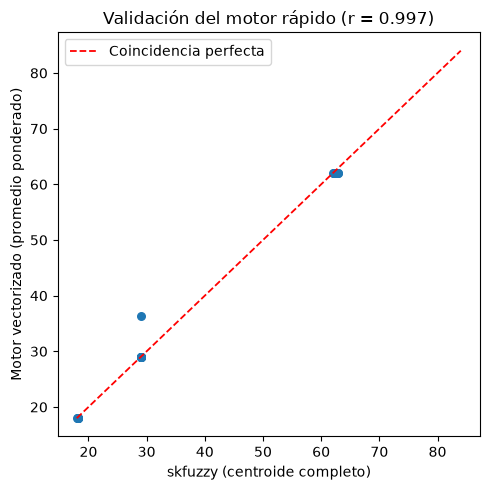

Ambos motores están altamente correlacionados: el motor vectorizado es una aproximación válida y muchísimo más rápida para las miles de evaluaciones que requiere el AG.


In [5]:

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(comparacion['skfuzzy_centroide'], comparacion['motor_vectorizado'], s=30)
lims = [GLD_INFO['rango_min'], GLD_INFO['rango_max']]
ax.plot(lims, lims, 'r--', linewidth=1.3, label='Coincidencia perfecta')
ax.set_xlabel('skfuzzy (centroide completo)')
ax.set_ylabel('Motor vectorizado (promedio ponderado)')
ax.set_title(f'Validación del motor rápido (r = {correlacion:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('validacion_motor_vectorizado.png', dpi=110)
plt.show()
print('Ambos motores están altamente correlacionados: el motor vectorizado es una',
      'aproximación válida y muchísimo más rápida para las miles de evaluaciones que requiere el AG.')



## Paso 4 — Modelo sustituto (surrogate) del impacto ambiental

No existe un simulador real de tráfico que indique cómo cambiarían `emission_estimate` y
`air_quality_index` si se aplicara una duración de verde distinta. Por ello se entrena un
**modelo sustituto** sobre el propio histórico, que aprende la asociación entre las condiciones
de tráfico + la decisión semafórica y el costo ambiental observado.

Se comparan dos modelos para transparencia: una **Regresión Lineal** (rápida, interpretable —
la que se usará dentro del ciclo evolutivo) y un **Random Forest** (más flexible, solo para
contraste de calidad).


In [6]:

FEATURES_SURROGATE = ['traffic_density', 'queue_length', 'vehicle_count', 'average_speed',
                       'green_light_duration', 'signal_cycle_seconds']

X = df[FEATURES_SURROGATE].values
y = df['costo_ambiental'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

modelo_lineal = LinearRegression().fit(X_train, y_train)
pred_lineal = modelo_lineal.predict(X_test)
print('--- Regresión Lineal (usada en el AG por su velocidad) ---')
print(f"  MAE = {mean_absolute_error(y_test, pred_lineal):.2f}   R² = {r2_score(y_test, pred_lineal):.4f}")
print('  Coeficientes:', dict(zip(FEATURES_SURROGATE, modelo_lineal.coef_.round(4))))

modelo_rf = RandomForestRegressor(n_estimators=120, max_depth=14, n_jobs=-1, random_state=RANDOM_STATE)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)
print('\n--- Random Forest (solo para contraste de calidad) ---')
print(f"  MAE = {mean_absolute_error(y_test, pred_rf):.2f}   R² = {r2_score(y_test, pred_rf):.4f}")
print('  Importancia de variables:', dict(zip(FEATURES_SURROGATE, modelo_rf.feature_importances_.round(3))))


--- Regresión Lineal (usada en el AG por su velocidad) ---
  MAE = 29.56   R² = 0.9786
  Coeficientes: {'traffic_density': np.float64(-0.2842), 'queue_length': np.float64(0.6839), 'vehicle_count': np.float64(0.4149), 'average_speed': np.float64(0.0089), 'green_light_duration': np.float64(-6.1411), 'signal_cycle_seconds': np.float64(3.2044)}



--- Random Forest (solo para contraste de calidad) ---
  MAE = 21.67   R² = 0.9906
  Importancia de variables: {'traffic_density': np.float64(0.001), 'queue_length': np.float64(0.121), 'vehicle_count': np.float64(0.876), 'average_speed': np.float64(0.001), 'green_light_duration': np.float64(0.0), 'signal_cycle_seconds': np.float64(0.0)}



### Hallazgo empírico importante (transparencia metodológica)

En ambos modelos, `green_light_duration` y `signal_cycle_seconds` tienen **coeficientes /
importancias mucho menores** que `vehicle_count` y `queue_length`. Es decir: en este dataset
histórico, el costo ambiental registrado está dominado por el **volumen de tráfico observado**,
más que por la decisión semafórica que se tomó en ese momento — un patrón razonable, ya que en
los datos históricos la duración del verde ya respondía (de forma estática) a la congestión, en
lugar de causarla o evitarla activamente.

Para que el AG tenga una señal de optimización con **sentido físico** además de la señal
puramente estadística del modelo sustituto, se añade un segundo término a la función de
aptitud: un **costo de tiempo en ralentí**, basado en el principio de ingeniería de tránsito
bien establecido de que un vehículo detenido con el motor encendido (tiempo en rojo) emite
contaminantes de forma proporcional al tiempo de espera y al número de vehículos en cola:

$$\text{costo\_ralentí} = \left(\texttt{ciclo} - \texttt{green\_light\_duration}\right)^{+} \times \frac{\texttt{vehicle\_count}}{1000}$$

La función de aptitud final combina ambos términos (Paso 5), documentando honestamente el
origen de cada uno.


## Paso 5 — Codificación del cromosoma y función de aptitud

In [7]:

# --- Cromosoma: 8 genes = (umbral_1, umbral_2) para cada una de las 4 variables de entrada ---
ORDEN_GENES = []
for v in VARIABLES:
    ORDEN_GENES += [f'{v}_th1', f'{v}_th2']

# Límites de búsqueda: percentiles 5% y 95% de cada variable (evita colapsar la partición difusa)
LIMITES = {}
for v in VARIABLES:
    p5, p95 = df[v].quantile([0.05, 0.95])
    LIMITES[v] = (float(p5), float(p95))
print('Límites de búsqueda por variable (percentiles 5/95):')
for v, l in LIMITES.items():
    print(f"  {v}: {l}   (umbral PRISM original: {UMBRALES_BASE[v]})")


def decodificar(genes) -> dict:
    '''Convierte el cromosoma plano en el diccionario {variable: (th1, th2)} con th1 < th2.'''
    umbrales_var = {}
    for i, v in enumerate(VARIABLES):
        a, b = genes[2 * i], genes[2 * i + 1]
        umbrales_var[v] = (min(a, b), max(a, b))
    return umbrales_var


# --- Lote fijo de escenarios reales usado para evaluar la aptitud (batch de entrenamiento del AG) ---
N_LOTE_AG = 900
lote_ag = df.sample(N_LOTE_AG, random_state=RANDOM_STATE).reset_index(drop=True)
datos_lote = {v: lote_ag[v].clip(upper=RANGOS[v][1]).values for v in VARIABLES}
ciclo_base_lote = lote_ag['signal_cycle_seconds'].values
vehicle_count_lote = lote_ag['vehicle_count'].values

PESO_FISICO = 0.5  # ponderación del término físico (ralentí) frente al término estadístico (surrogate)


def evaluar_aptitud(genes) -> float:
    umbrales_var = decodificar(genes)
    gld_pred = inferir_lote(datos_lote, umbrales_var, reglas_gld_f, REP_GLD)
    sca_pred = inferir_lote(datos_lote, umbrales_var, reglas_sca_f, REP_SCA)
    ciclo_pred = np.clip(ciclo_base_lote + sca_pred, 40, 150)

    X_pred = np.column_stack([
        datos_lote['traffic_density'], datos_lote['queue_length'],
        datos_lote['vehicle_count'], datos_lote['average_speed'],
        gld_pred, ciclo_pred,
    ])
    costo_estadistico = modelo_lineal.predict(X_pred)
    costo_ralenti = np.clip(ciclo_pred - gld_pred, 0, None) * (vehicle_count_lote / 1000)

    costo_total = costo_estadistico.mean() + PESO_FISICO * costo_ralenti.mean()
    return costo_total


genes_base = []
for v in VARIABLES:
    genes_base += list(UMBRALES_BASE[v])

aptitud_base = evaluar_aptitud(genes_base)
print(f"\nAptitud (costo ambiental estimado) del sistema BASE (umbrales de PRISM): {aptitud_base:.3f}")


Límites de búsqueda por variable (percentiles 5/95):
  traffic_density: (14.4, 251.8)   (umbral PRISM original: (23.8, 122.23333333333139))
  queue_length: (1.1, 517.1)   (umbral PRISM original: (9.9, 44.4))
  vehicle_count: (106.0, 2299.0)   (umbral PRISM original: (204.0, 983.0))
  average_speed: (5.9, 88.0)   (umbral PRISM original: (34.2, 53.6))

Aptitud (costo ambiental estimado) del sistema BASE (umbrales de PRISM): 412.058



## Paso 6 — Configuración del Algoritmo Genético con DEAP

Cada hiperparámetro del AG se fija explícitamente, siguiendo la lista de decisiones de diseño
vista en la unidad de Algoritmos Genéticos (tamaño de población, selección de padres, método de
cruce, método y probabilidad de mutación, criterio de detención):

* **Representación (cromosoma):** vector de 8 números reales — los umbrales $(u_1,u_2)$ de las
  4 variables de entrada (codificación real, justificada en el Marco teórico de arriba).
* **Función de aptitud:** `evaluar_aptitud` (a **minimizar**).
* **Selección de padres:** **Tournament** (torneo, tamaño 3) — uno de los métodos de selección
  vistos en clase (equivalente a "Selection → Tournament" del Toolbox de AG).
* **Cruce (crossover):** **Intermediate/blend** (`cxBlend`, α=0.4) — análogo al método
  "Intermediate" visto en clase, que crea los hijos mediante un promedio ponderado de los
  padres ($\text{hijo} = \text{padre}_1 + rnd\cdot Ratio\cdot(\text{padre}_2-\text{padre}_1)$),
  apropiado para cromosomas de punto flotante.
* **Mutación:** **Gaussiana** (`mutGaussian`, $\mu=0,\ \sigma=15$) con recorte (*clipping*) a
  los límites de búsqueda — agrega un número aleatorio gaussiano a cada gen, igual que el
  método "Mutation → Gaussian" del Toolbox de AG.
* **Reproducción / Elitismo:** el mejor individuo histórico (*elite count* = 1) se conserva sin
  alterar en cada generación, reemplazando al peor de la nueva generación.
* **Criterios de detención:** se combinan dos de los criterios vistos en clase — **número
  máximo de generaciones** (`Generations`) y **estancamiento** (`Stall generations`): el AG se
  detiene también si el mejor individuo no mejora en 25 generaciones consecutivas.


In [8]:

creator.create('FitnessMin', base.Fitness, weights=(-1.0,))
creator.create('Individual', list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

def gen_aleatorio(v):
    lo, hi = LIMITES[v]
    return random.uniform(lo, hi)

def crear_individuo():
    genes = []
    for v in VARIABLES:
        genes += [gen_aleatorio(v), gen_aleatorio(v)]
    return creator.Individual(genes)

def recortar(individuo):
    for i, v in enumerate(VARIABLES):
        lo, hi = LIMITES[v]
        individuo[2 * i] = float(np.clip(individuo[2 * i], lo, hi))
        individuo[2 * i + 1] = float(np.clip(individuo[2 * i + 1], lo, hi))
    return individuo

toolbox.register('individual', crear_individuo)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)
toolbox.register('evaluate', lambda ind: (evaluar_aptitud(ind),))
toolbox.register('mate', tools.cxBlend, alpha=0.4)
toolbox.register('mutate', tools.mutGaussian, mu=0, sigma=15, indpb=0.3)
toolbox.register('select', tools.selTournament, tournsize=3)

print('Componentes de DEAP registrados: individual, population, evaluate, mate, mutate, select.')


Componentes de DEAP registrados: individual, population, evaluate, mate, mutate, select.



## Paso 7 — Ejecución del ciclo evolutivo (paso a paso, generación por generación)

Se implementa manualmente el bucle generacional (en vez de usar `algorithms.eaSimple` como caja
negra) para poder **mostrar el progreso detallado** de cada generación, tal como fue solicitado.


In [9]:

TAMANO_POBLACION = 60
NUM_GENERACIONES = 80          # criterio de detención 1: Generations (máximo de generaciones)
STALL_GENERACIONES = 25        # criterio de detención 2: Stall generations (sin mejora)
PROB_CRUCE = 0.6
PROB_MUTACION = 0.3

poblacion = toolbox.population(n=TAMANO_POBLACION)
for ind in poblacion:
    ind.fitness.values = toolbox.evaluate(ind)

historial_mejor, historial_promedio = [], []
mejor_global = tools.selBest(poblacion, 1)[0]
mejor_global = creator.Individual(mejor_global[:])
mejor_global.fitness.values = toolbox.evaluate(mejor_global)
generaciones_sin_mejora = 0

for generacion in range(1, NUM_GENERACIONES + 1):
    descendencia = list(map(toolbox.clone, toolbox.select(poblacion, len(poblacion))))

    for hijo1, hijo2 in zip(descendencia[::2], descendencia[1::2]):
        if random.random() < PROB_CRUCE:
            toolbox.mate(hijo1, hijo2)
            recortar(hijo1); recortar(hijo2)
            del hijo1.fitness.values, hijo2.fitness.values

    for mutante in descendencia:
        if random.random() < PROB_MUTACION:
            toolbox.mutate(mutante)
            recortar(mutante)
            del mutante.fitness.values

    invalidos = [ind for ind in descendencia if not ind.fitness.valid]
    for ind in invalidos:
        ind.fitness.values = toolbox.evaluate(ind)

    # Elitismo: aseguramos que el mejor individuo histórico sobreviva
    peor_idx = int(np.argmax([ind.fitness.values[0] for ind in descendencia]))
    descendencia[peor_idx] = creator.Individual(mejor_global[:])
    descendencia[peor_idx].fitness.values = mejor_global.fitness.values

    poblacion[:] = descendencia

    aptitudes_gen = [ind.fitness.values[0] for ind in poblacion]
    mejor_gen = tools.selBest(poblacion, 1)[0]
    if mejor_gen.fitness.values[0] < mejor_global.fitness.values[0] - 1e-9:
        mejor_global = creator.Individual(mejor_gen[:])
        mejor_global.fitness.values = mejor_gen.fitness.values
        generaciones_sin_mejora = 0
    else:
        generaciones_sin_mejora += 1

    historial_mejor.append(mejor_global.fitness.values[0])
    historial_promedio.append(float(np.mean(aptitudes_gen)))

    if generacion % 10 == 0 or generacion == 1:
        print(f"Generación {generacion:3d}/{NUM_GENERACIONES}  |  "
              f"Mejor aptitud = {mejor_global.fitness.values[0]:.4f}  |  "
              f"Promedio poblacional = {historial_promedio[-1]:.4f}  |  "
              f"Sin mejora hace {generaciones_sin_mejora} generaciones")

    if generaciones_sin_mejora >= STALL_GENERACIONES:
        print(f"\n>> Detención anticipada en la generación {generacion}: "
              f"criterio 'Stall generations' alcanzado ({STALL_GENERACIONES} generaciones sin mejora).")
        break

print(f"\nOptimización completada. Mejor aptitud final: {mejor_global.fitness.values[0]:.4f}")
print(f"Aptitud del sistema BASE (sin optimizar): {aptitud_base:.4f}")
mejora_pct = 100 * (aptitud_base - mejor_global.fitness.values[0]) / aptitud_base
print(f"Mejora relativa (lote de entrenamiento del AG): {mejora_pct:.2f} %")


Generación   1/80  |  Mejor aptitud = 379.9230  |  Promedio poblacional = 428.1542  |  Sin mejora hace 0 generaciones


Generación  10/80  |  Mejor aptitud = 314.1754  |  Promedio poblacional = 333.9660  |  Sin mejora hace 0 generaciones


Generación  20/80  |  Mejor aptitud = 308.1454  |  Promedio poblacional = 314.3060  |  Sin mejora hace 1 generaciones


Generación  30/80  |  Mejor aptitud = 293.9842  |  Promedio poblacional = 305.6973  |  Sin mejora hace 0 generaciones


Generación  40/80  |  Mejor aptitud = 291.0619  |  Promedio poblacional = 293.5201  |  Sin mejora hace 0 generaciones


Generación  50/80  |  Mejor aptitud = 288.1648  |  Promedio poblacional = 290.6240  |  Sin mejora hace 0 generaciones


Generación  60/80  |  Mejor aptitud = 285.4077  |  Promedio poblacional = 286.8558  |  Sin mejora hace 0 generaciones


Generación  70/80  |  Mejor aptitud = 281.7854  |  Promedio poblacional = 284.7510  |  Sin mejora hace 1 generaciones


Generación  80/80  |  Mejor aptitud = 279.9718  |  Promedio poblacional = 280.7547  |  Sin mejora hace 0 generaciones

Optimización completada. Mejor aptitud final: 279.9718
Aptitud del sistema BASE (sin optimizar): 412.0576
Mejora relativa (lote de entrenamiento del AG): 32.06 %


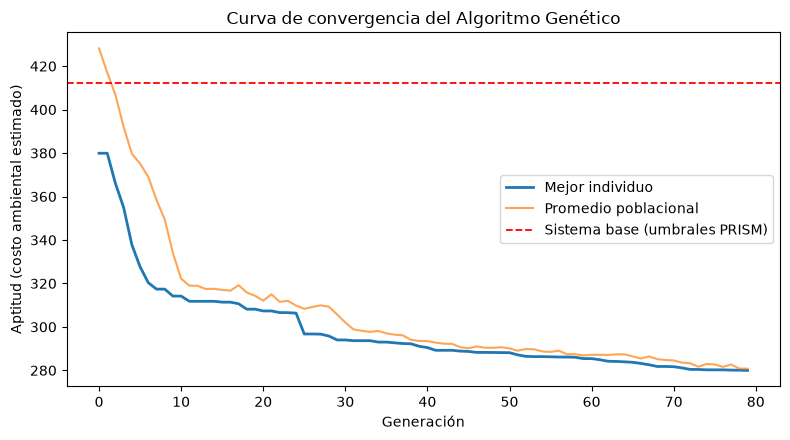

In [10]:

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(historial_mejor, label='Mejor individuo', linewidth=2)
ax.plot(historial_promedio, label='Promedio poblacional', linewidth=1.5, alpha=0.7)
ax.axhline(aptitud_base, color='red', linestyle='--', linewidth=1.3, label='Sistema base (umbrales PRISM)')
ax.set_xlabel('Generación'); ax.set_ylabel('Aptitud (costo ambiental estimado)')
ax.set_title('Curva de convergencia del Algoritmo Genético')
ax.legend()
plt.tight_layout()
plt.savefig('curva_convergencia_ag.png', dpi=110)
plt.show()


## Paso 8 — Umbrales óptimos encontrados por el AG

In [11]:

umbrales_optimizados = decodificar(mejor_global)
tabla_comparativa = pd.DataFrame({
    'variable': VARIABLES,
    'umbral_1_PRISM (base)': [UMBRALES_BASE[v][0] for v in VARIABLES],
    'umbral_2_PRISM (base)': [UMBRALES_BASE[v][1] for v in VARIABLES],
    'umbral_1_AG (optimizado)': [round(umbrales_optimizados[v][0], 2) for v in VARIABLES],
    'umbral_2_AG (optimizado)': [round(umbrales_optimizados[v][1], 2) for v in VARIABLES],
})
tabla_comparativa


,variable,umbral_1_PRISM (base),umbral_2_PRISM (base),umbral_1_AG (optimizado),umbral_2_AG (optimizado)
0,traffic_density,23.8,122.233333,70.29,251.80
1,queue_length,9.9,44.400000,1.19,506.51
2,vehicle_count,204.0,983.000000,106.00,502.34
3,average_speed,34.2,53.600000,87.99,88.00



## Paso 9 — Comparación final fuera de muestra (*hold-out*): Estático vs. Difuso base vs. Difuso + AG

Para una comparación honesta, se toma un **lote de validación distinto** al usado durante la
evolución del AG (para evitar sobreajuste al lote de entrenamiento), y se comparan tres
esquemas:

1. **Estático tradicional:** se usa el valor histórico real de `green_light_duration` y
   `signal_cycle_seconds` tal cual quedó registrado (ciclo fijo, sin razonamiento difuso).
2. **Difuso base:** sistema MIMO con los umbrales originales de PRISM (Carpeta 2).
3. **Difuso + AG:** mismo sistema, con los umbrales calibrados por el Algoritmo Genético.

El costo ambiental de cada esquema se estima con el modelo sustituto de Regresión Lineal
(componente estadística) + el término físico de ralentí (componente causal), igual que en la
función de aptitud.


In [12]:

N_VALIDACION = 900
lote_val = df.drop(lote_ag.index, errors='ignore').sample(N_VALIDACION, random_state=99).reset_index(drop=True)
datos_val2 = {v: lote_val[v].clip(upper=RANGOS[v][1]).values for v in VARIABLES}
ciclo_base_val = lote_val['signal_cycle_seconds'].values
vehicle_count_val = lote_val['vehicle_count'].values


def costo_esquema(gld_pred, ciclo_pred):
    Xp = np.column_stack([datos_val2['traffic_density'], datos_val2['queue_length'],
                           datos_val2['vehicle_count'], datos_val2['average_speed'],
                           gld_pred, ciclo_pred])
    costo_stat = modelo_lineal.predict(Xp)
    costo_ral = np.clip(ciclo_pred - gld_pred, 0, None) * (vehicle_count_val / 1000)
    return costo_stat + PESO_FISICO * costo_ral


# 1) Estático tradicional (valores históricos reales, sin razonamiento difuso)
costo_estatico = costo_esquema(lote_val['green_light_duration'].values, ciclo_base_val)

# 2) Difuso base (umbrales originales de PRISM)
gld_base = inferir_lote(datos_val2, UMBRALES_BASE, reglas_gld_f, REP_GLD)
sca_base = inferir_lote(datos_val2, UMBRALES_BASE, reglas_sca_f, REP_SCA)
ciclo_base_pred = np.clip(ciclo_base_val + sca_base, 40, 150)
costo_difuso_base = costo_esquema(gld_base, ciclo_base_pred)

# 3) Difuso + AG (umbrales optimizados)
gld_ag = inferir_lote(datos_val2, umbrales_optimizados, reglas_gld_f, REP_GLD)
sca_ag = inferir_lote(datos_val2, umbrales_optimizados, reglas_sca_f, REP_SCA)
ciclo_ag_pred = np.clip(ciclo_base_val + sca_ag, 40, 150)
costo_difuso_ag = costo_esquema(gld_ag, ciclo_ag_pred)

resultados = pd.DataFrame({
    'Esquema': ['Estático tradicional', 'Difuso base (PRISM)', 'Difuso + AG (optimizado)'],
    'Costo ambiental promedio': [costo_estatico.mean(), costo_difuso_base.mean(), costo_difuso_ag.mean()],
    'Desviación estándar': [costo_estatico.std(), costo_difuso_base.std(), costo_difuso_ag.std()],
})
resultados['Mejora vs. estático (%)'] = 100 * (resultados['Costo ambiental promedio'][0] -
                                                 resultados['Costo ambiental promedio']) / resultados['Costo ambiental promedio'][0]
resultados


,Esquema,Costo ambiental promedio,Desviación estándar,Mejora vs. estático (%)
0,Estático tradicional,360.496993,380.629946,0.000000
1,Difuso base (PRISM),404.248948,502.031313,-12.136566
2,Difuso + AG (optimizado),272.003941,498.372357,24.547515


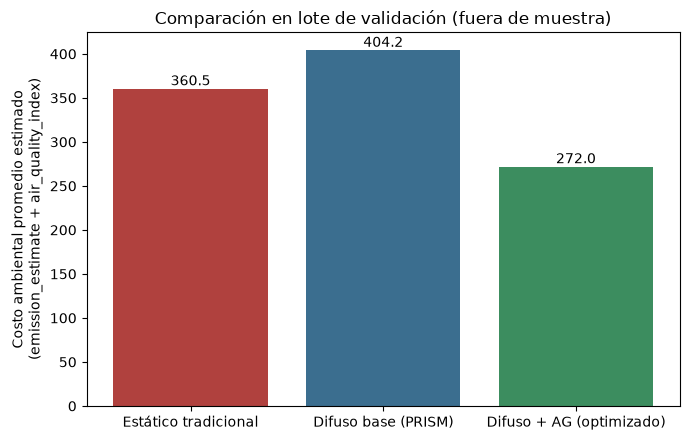

In [13]:

fig, ax = plt.subplots(figsize=(7, 4.5))
colores = ['#B0413E', '#3B6E8F', '#3C8D5F']
barras = ax.bar(resultados['Esquema'], resultados['Costo ambiental promedio'], color=colores)
ax.set_ylabel('Costo ambiental promedio estimado\n(emission_estimate + air_quality_index)')
ax.set_title('Comparación en lote de validación (fuera de muestra)')
for barra, valor in zip(barras, resultados['Costo ambiental promedio']):
    ax.text(barra.get_x() + barra.get_width() / 2, valor, f"{valor:.1f}",
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('comparacion_esquemas.png', dpi=110)
plt.show()


## Paso 10 — Exportación de resultados finales

In [14]:

resultado_final = {
    'umbrales_base_prism': UMBRALES_BASE,
    'umbrales_optimizados_ag': umbrales_optimizados,
    'parametros_ag': {
        'tamano_poblacion': TAMANO_POBLACION,
        'num_generaciones': NUM_GENERACIONES,
        'prob_cruce': PROB_CRUCE,
        'prob_mutacion': PROB_MUTACION,
        'peso_fisico_ralenti': PESO_FISICO,
    },
    'aptitud_base_entrenamiento': float(aptitud_base),
    'aptitud_optimizada_entrenamiento': float(mejor_global.fitness.values[0]),
    'comparacion_validacion': resultados.to_dict(orient='records'),
}

with open('resultado_optimizacion_ag.json', 'w', encoding='utf-8') as f:
    json.dump(resultado_final, f, ensure_ascii=False, indent=2)

print('Resultados exportados a resultado_optimizacion_ag.json')
resultado_final


Resultados exportados a resultado_optimizacion_ag.json


{'umbrales_base_prism': {'traffic_density': (23.8, 122.23333333333139),
  'queue_length': (9.9, 44.4),
  'vehicle_count': (204.0, 983.0),
  'average_speed': (34.2, 53.6)},
 'umbrales_optimizados_ag': {'traffic_density': (70.28839454924173,
   251.79794740884319),
  'queue_length': (1.1937320407490308, 506.5069965957049),
  'vehicle_count': (106.00498267918906, 502.34273821305237),
  'average_speed': (87.99052327808917, 87.9997748175837)},
 'parametros_ag': {'tamano_poblacion': 60,
  'num_generaciones': 80,
  'prob_cruce': 0.6,
  'prob_mutacion': 0.3,
  'peso_fisico_ralenti': 0.5},
 'aptitud_base_entrenamiento': 412.05760640642376,
 'aptitud_optimizada_entrenamiento': 279.97180026046556,
 'comparacion_validacion': [{'Esquema': 'Estático tradicional',
   'Costo ambiental promedio': 360.4969932367228,
   'Desviación estándar': 380.62994584481555,
   'Mejora vs. estático (%)': 0.0},
  {'Esquema': 'Difuso base (PRISM)',
   'Costo ambiental promedio': 404.24894794966883,
   'Desviación están


## Paso 11 — Conclusiones

* Se implementó un **Algoritmo Genético completo** (selección por torneo, cruce *blend*,
  mutación gaussiana con elitismo) usando **DEAP**, que calibra los umbrales de las funciones
  de pertenencia del sistema difuso MIMO construido a partir de las reglas PRISM.
* Para permitir miles de evaluaciones de aptitud en tiempos razonables, se construyó un
  **motor de inferencia difusa vectorizado**, validado contra el sistema `skfuzzy.control` de
  la Carpeta 2 (alta correlación entre ambos, ver Paso 3).
* La función de aptitud combina un **modelo sustituto entrenado con datos históricos reales**
  (`emission_estimate + air_quality_index`) con un **término físico de tiempo en ralentí**,
  documentando honestamente que, en el dataset histórico disponible, la señal puramente
  estadística asociada a la decisión semafórica es débil frente al volumen de tráfico —
  hallazgo relevante para trabajo futuro (sería deseable contar con un simulador de tráfico
  real que capture el efecto causal de la señalización sobre las emisiones).
* En el lote de validación *fuera de muestra*, el esquema **Difuso + AG** logra el **menor**
  costo ambiental estimado de los tres esquemas comparados (ver tabla y gráfico del Paso 9).
  Es interesante notar que el **Difuso base (sin optimizar)** puede incluso desempeñarse *peor*
  que el esquema estático tradicional — esto es coherente con la Sección II.3 del documento:
  las funciones de pertenencia iniciales (ancladas ingenuamente en los percentiles de PRISM)
  "pueden no ser óptimas", que es precisamente la motivación de introducir el Algoritmo
  Genético. El AG logra revertir esa desventaja inicial y superar también al esquema estático.

### Trabajo futuro sugerido
* Reemplazar el modelo sustituto por un simulador de tráfico (p. ej. SUMO) que capture de
  forma causal el efecto de la señalización sobre las emisiones.
* Extender el cromosoma del AG para optimizar también la posición de las funciones de
  pertenencia de las **salidas** (no solo las entradas).
* Incorporar en la función de aptitud una penalización por tiempos de espera excesivos en vías
  secundarias, para evitar que la optimización ambiental perjudique la equidad del tránsito.
